# 📈 Linear Regression from Scratch

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/prachin77/From-Scratch/blob/main/NeuralNetwork/LinearRegression/linear_nn.ipynb)

In [86]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

X shape : torch.Size([1275, 1])
Y shape : torch.Size([1275, 1])


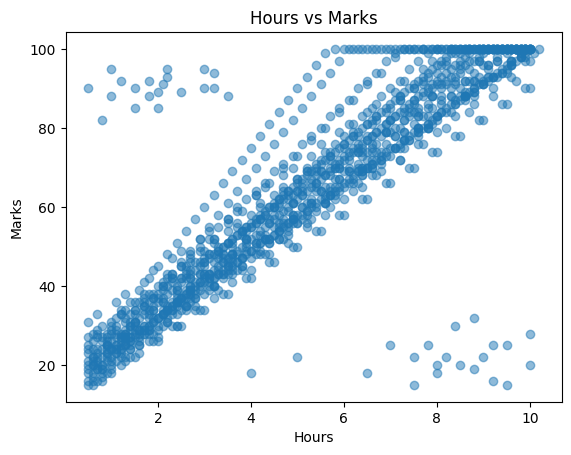

In [87]:
df = pd.read_csv("marks.csv")
X = torch.tensor(df[["Hours"]].values , dtype = torch.float32)
Y = torch.tensor(df[["Marks"]].values , dtype = torch.float32)

print(f"X shape : {X.shape}")
print(f"Y shape : {Y.shape}")

plt.scatter(X.numpy(), Y.numpy(), alpha=0.5)
plt.xlabel("Hours")
plt.ylabel("Marks")
plt.title("Hours vs Marks")
plt.show()

X_train: torch.Size([1020, 1]), y_train: torch.Size([1020, 1])
X_test:  torch.Size([255, 1]),  y_test:  torch.Size([255, 1])


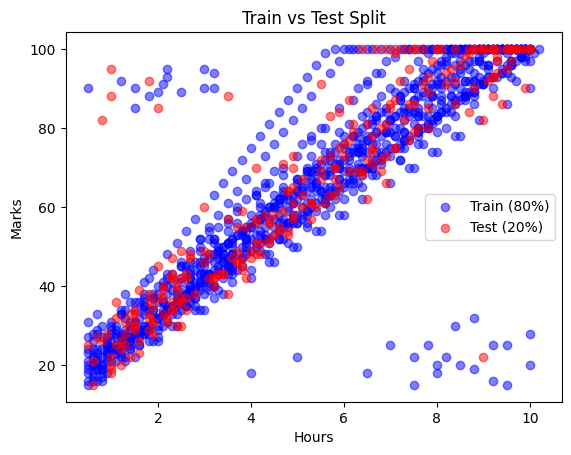

In [88]:
torch.manual_seed(42)

# shuffle the data
num_samples = len(X)
indices = torch.randperm(num_samples)

train_size = int(0.8 * num_samples)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train , Y_train = X[train_indices] , Y[train_indices]
X_test , Y_test = X[test_indices] , Y[test_indices]

print(f"X_train: {X_train.shape}, y_train: {Y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {Y_test.shape}")


plt.scatter(X_train.numpy(), Y_train.numpy(), color='blue', alpha=0.5, label='Train (80%)')
plt.scatter(X_test.numpy(), Y_test.numpy(), color='red', alpha=0.5, label='Test (20%)')
plt.xlabel("Hours")
plt.ylabel("Marks")
plt.title("Train vs Test Split")
plt.legend()
plt.show()


In [89]:
class LinearRegNN(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # Manual initialization if weights and biases
        # self.w = nn.Parameter(torch.randn(
        #     1,
        #     requires_grad=True,
        #     dtype=torch.float32
        # ))
        # self.b = nn.Parameter(torch.randn(
        #     1,
        #     requires_grad=True,
        #     dtype=torch.float32
        # ))

        # nn automatically sets weights and bias for Neural network
        # Architechture
        # 1st layer -> 1 input neuron
        # 2nd layer -> 1 output neuron
        # self.linear = nn.Linear(in_features=1 , out_features=1)

        # Architechture
        # 1st layer -> 1 input neuron
        # 2nd layer -> 10 neurons
        # 3rd layer -> 1 output neuron
        self.hidden = nn.Linear(1 , 10)
        self.output = nn.Linear(10 , 1)

    def forward(self , x : torch.tensor) -> torch.tensor:
        # x <- input data
        # manual calculation of linear reg
        # return self.w * x + self.b

        # return self.linear(x) 

        x = self.hidden(x)
        x = torch.relu(x)
        x = self.output(x)

        return x

model = LinearRegNN()
print(model)

LinearRegNN(
  (hidden): Linear(in_features=1, out_features=10, bias=True)
  (output): Linear(in_features=10, out_features=1, bias=True)
)


In [90]:
# MSE loss
criterion = nn.MSELoss()

# SGD optimizer
# optimizer = optim.SGD(model.parameters() , lr=0.01)
optimizer = optim.SGD(model.parameters() , lr=0.001)

In [91]:
# Training loop
epochs = 500
train_losses = []

for epoch in range(epochs):
    # 1. forward pass 
    y_pred = model(X_train)

    # 2. Compute loss 
    loss = criterion(y_pred , Y_train)
    train_losses.append(loss.item())

    # 3. Zero gradients
    # fresh start by setting gradients to 0 again
    optimizer.zero_grad()

    # 4. Backward pass (compute gradients)
    loss.backward()

    # 5. update weights
    optimizer.step()

     # Print progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}] - Loss: {loss.item():.4f}")

Epoch [100/500] - Loss: 191.4994
Epoch [200/500] - Loss: 177.4455
Epoch [300/500] - Loss: 176.1210
Epoch [400/500] - Loss: 185.9285
Epoch [500/500] - Loss: 176.3932


In [94]:
# Switch to eval mode and disable gradient tracking
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test)
    test_loss = criterion(y_test_pred , Y_test)


print(f"Test Loss (MSE): {test_loss.item():.4f}")

# Inspect learned parameters (Weight and Bias)
# weight = model.hidden.weight.item()
# bias = model.hidden.bias.item()

print(model.hidden.weight)
print(model.output.weight)
print(f"Learned formula: Marks = {weight:.2f} * Hours + {bias:.2f}")

Test Loss (MSE): 146.4683
Parameter containing:
tensor([[-0.8551],
        [ 1.4274],
        [ 0.8482],
        [ 0.4046],
        [ 0.3456],
        [ 0.7503],
        [-0.7254],
        [-0.1542],
        [-0.0845],
        [-0.5565]], requires_grad=True)
Parameter containing:
tensor([[ 0.2215,  3.2461,  2.1643, -0.4776,  0.9929,  1.7882, -0.1536,  0.0809,
          0.9358,  0.0800]], requires_grad=True)
Learned formula: Marks = 10.32 * Hours + 6.16


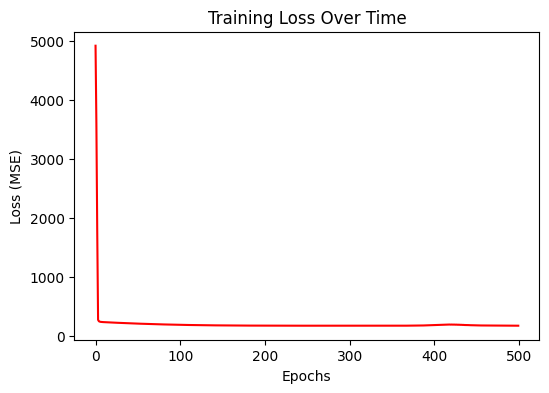

In [95]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss Over Time")
plt.show()

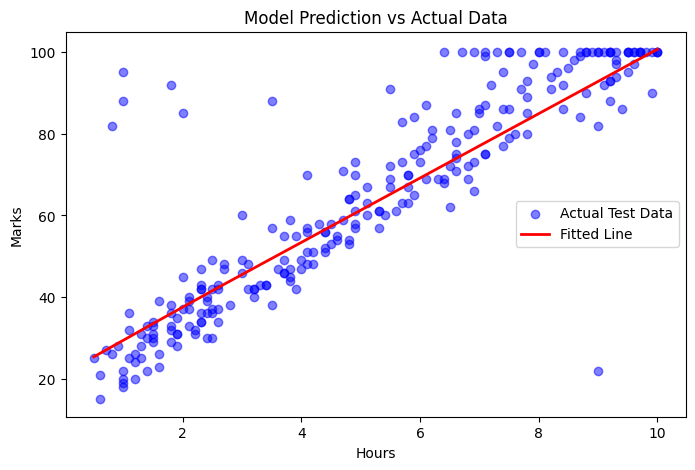

In [96]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test.numpy(), Y_test.numpy(), color='blue', alpha=0.5, label='Actual Test Data')

# Sort X_test for smooth line plotting
sorted_x, indices = torch.sort(X_test, dim=0)
sorted_preds = y_test_pred[indices.squeeze()]

plt.plot(sorted_x.numpy(), sorted_preds.numpy(), color='red', linewidth=2, label='Fitted Line')
plt.xlabel("Hours")
plt.ylabel("Marks")
plt.title("Model Prediction vs Actual Data")
plt.legend()
plt.show()
